%% [markdown]
# Capítulo 8: Event-Driven — Merger Arbitrage con ETFs
*Proxy de arbitraje de fusiones usando ETFs sectoriales en descuento*
 
**Estrategia:** Detectar ETFs de sectores objetivo de M&A que caen >25% desde máximos con volumen anómalo (>2x media). Entrar en el descuento, salir al recuperar 50% de la caída o tras 6 meses.

**Advertencia:** Esto NO es merger arbitrage puro. Es un proxy pedagógico que simula la lógica de entrar en dislocaciones por miedo a M&A fallido.

**Objetivo:** Demostrar si esta aproximación genera alpha vs. Buy & Hold, y documentar las limitaciones de trabajar sin datos de eventos en tiempo real.

##⚠️ Advertencia de honestidad intelectual
El Merger Arbitrage puro (comprar el target de una OPA y vender el adquirente para capturar el spread de convergencia) requiere:

    Datos de OPAs en tiempo real (anuncios, probabilidades de cierre, fechas de vencimiento).
    Spreads de convergencia entre el precio del target y el precio de oferta.
    Análisis de riesgo regulatorio (antitrust, aprobaciones gubernamentales).

Yahoo Finance no proporciona estos datos. Por eso, lo que vamos a construir en este capítulo es un proxy simplificado: una estrategia que detecta "sectores en descuento por miedo a M&A fallido" basándose en caídas bruscas con volumen anómalo.
Esto NO es merger arbitrage real. Es una aproximación pedagógica que nos permite:

    Entender la lógica del event-driven (entrar en dislocaciones, salir en convergencia).
    Medir si este tipo de señales genera alpha vs. Buy & Hold.
    Documentar las limitaciones de trabajar sin datos de eventos en tiempo real.

## BLOQUE 0: CONFIGURACIÓN — EVENT-DRIVEN

In [1]:
# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN — EVENT-DRIVEN
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
COSTE_TRANSACCION    = 0.001       # 0.1% por operación
BENCHMARK            = 'SPY'

# --- Rango temporal ---
FECHA_INICIO = '2015-01-01'
FECHA_FIN    = '2025-08-15'

# --- Parámetros de detección de eventos ---
UMBRAL_CAIDA         = 0.25        # Caída mínima desde máximo (25%)
MULTIPLICADOR_VOLUMEN = 2.0         # Volumen debe ser >2x la media
VENTANA_MAXIMO       = 252         # Días para calcular máximo histórico
VENTANA_VOLUMEN      = 20          # Días para calcular volumen medio
PLAZO_MAXIMO_DIAS    = 126         # 6 meses máximo en posición
RECUPERACION_MINIMA  = 0.50        # Salir al recuperar 50% de la caída

# --- Universo de ETFs sectoriales (objetivo de M&A) ---
UNIVERSO_EVENT = {
    'biotech': {
        'SPDR S&P Biotech':       {'isin': 'XBI', 'ticker': 'XBI'},
        'iShares Biotechnology':  {'isin': 'IBB', 'ticker': 'IBB'},
    },
    'bancos': {
        'SPDR S&P Bank ETF':      {'isin': 'KBE', 'ticker': 'KBE'},
    },
    'retail': {
        'SPDR S&P Retail':        {'isin': 'XRT', 'ticker': 'XRT'},
    },
    'semiconductores': {
        'VanEck Semiconductor':   {'isin': 'SMH', 'ticker': 'SMH'},
    },
    'cash': {
        'iShares 1-3 Year Treasury': {'isin': 'SHY', 'ticker': 'SHY'},
    },
    'benchmark': {
        'SPDR S&P 500':           {'isin': 'SPY', 'ticker': 'SPY'},
    }
}

print("✅ Configuración Event-Driven cargada:")
print(f"   • ETFs candidatos: {sum(len(v) for k, v in UNIVERSO_EVENT.items() if k != 'cash' and k != 'benchmark')}")
print(f"   • Umbral de caída: {UMBRAL_CAIDA:.0%}")
print(f"   • Multiplicador de volumen: {MULTIPLICADOR_VOLUMEN}x")
print(f"   • Plazo máximo: {PLAZO_MAXIMO_DIAS} días")
print(f"   • Recuperación mínima para salida: {RECUPERACION_MINIMA:.0%}")

✅ Configuración Event-Driven cargada:
   • ETFs candidatos: 5
   • Umbral de caída: 25%
   • Multiplicador de volumen: 2.0x
   • Plazo máximo: 126 días
   • Recuperación mínima para salida: 50%


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================
print("="*70)
print("⚠️  AVISO LEGAL: Fines exclusivamente educativos e investigativos.")
print("="*70)

import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Búsqueda de core
def buscar_core():
    try:
        import ipykernel
        from jupyter_server import serverapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")

try:
    from core import (
        GestorProyecto, GestorDatos, MotorBacktestDinamico,
        CalculadorMetricas, CalculadorMetricasExtras, GeneradorInformes
    )
    print("✅ Módulos importados correctamente.")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    raise

BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()

⚠️  AVISO LEGAL: Fines exclusivamente educativos e investigativos.
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos importados correctamente.


## Bloques 2 y 3: Limpieza y Fechas

In [3]:
# %%
# ==============================================================================
# BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# ==============================================================================
gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
gestor_proyecto.imprimir_resumen()
gestor_proyecto.menu_limpieza_directorios()

# %%
# ==============================================================================
# BLOQUE 3: GESTIÓN DE FECHAS
# ==============================================================================
fecha_ini = FECHA_INICIO
fecha_fin = FECHA_FIN
nombre_evento = "Event-Driven Proxy (2015-2025)"
print(f"\n🎯 Rango temporal: {nombre_evento} | {fecha_ini} → {fecha_fin}")

📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_investing
📁 DATOS_FI_MYI


¿Qué directorios deseas VACIAR? (ej: 3,5,7 / 'todos' / 'ninguno'):  5



🧹 Iniciando limpieza...
   🗑️  Vaciando 'DATOS_CSV'...
      ✅ 'DATOS_CSV' limpiado.

🎯 Rango temporal: Event-Driven Proxy (2015-2025) | 2015-01-01 → 2025-08-15


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [4]:
# %%
# ==============================================================================
# BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# ==============================================================================
gestor = GestorDatos(
    diccionario_datos=UNIVERSO_EVENT,
    fecha_inicio=fecha_ini,
    fecha_fin=fecha_fin,
    gestor_proyecto=gestor_proyecto
)

print(f"\n📊 GestorDatos inicializado con {len(UNIVERSO_EVENT)} categorías.")
continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló.")
else:
    print("\n✅ Datos preparados.")


📊 GestorDatos inicializado con 6 categorías.

 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  1



🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...

📊 Procesando 7 activos...

   📊 SPDR S&P Biotech
      ✅ Descargado con ticker: XBI

   📊 iShares Biotechnology
      ✅ Descargado con ticker: IBB

   📊 SPDR S&P Bank ETF
      ✅ Descargado con ticker: KBE

   📊 SPDR S&P Retail
      ✅ Descargado con ticker: XRT

   📊 VanEck Semiconductor
      ✅ Descargado con ticker: SMH

   📊 iShares 1-3 Year Treasury
      ✅ Descargado con ticker: SHY

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

📊 Resumen: 7 descargados, 0 omitidos



Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,SPDR S&P Biotech,XBI,2670,2015-01-02,2025-08-14,CSV
1,iShares Biotechnology,IBB,2670,2015-01-02,2025-08-14,CSV
2,SPDR S&P Bank ETF,KBE,2670,2015-01-02,2025-08-14,CSV
3,SPDR S&P Retail,XRT,2670,2015-01-02,2025-08-14,CSV
4,VanEck Semiconductor,SMH,2670,2015-01-02,2025-08-14,CSV
5,iShares 1-3 Year Treasury,SHY,2670,2015-01-02,2025-08-14,CSV
6,SPDR S&P 500,SPY,2670,2015-01-02,2025-08-14,CSV


✅ 7 activos alineados para el Motor Backtest.


✅ Datos preparados.


## BLOQUE 5: DETECCIÓN DE EVENTOS Y GENERADOR DE PESOS

In [5]:
# %%
# ==============================================================================
# BLOQUE 5: DETECCIÓN DE EVENTOS Y GENERADOR DE PESOS
# ==============================================================================
print("\n" + "="*70)
print("🔍 DETECCIÓN DE EVENTOS: CAÍDAS + VOLUMEN ANÓMALO")
print("="*70)

if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios. Ejecuta Bloque 4 primero.")
else:
    print(f"\n📊 Datos: {len(gestor.precios_ajustados)} filas")
    
    # ==================================================================
    # MAPEO DE TICKERS A COLUMNAS REALES
    # ==================================================================
    print("\n🔍 Mapeando tickers a columnas reales...")
    
    mapeo_tickers = {}
    for _, row in gestor.valores_seleccionados.iterrows():
        ticker = str(row.get('ticker', '')).strip().upper()
        nombre = str(row.get('nombre', '')).strip()
        nombre_limpio = nombre.replace(" ", "_").replace(".", "").replace(",", "").replace("!", "")
        if ticker:
            mapeo_tickers[ticker] = nombre_limpio
    
    # ETFs candidatos (sin cash ni benchmark)
    etfs_candidatos = ['XBI', 'IBB', 'KBE', 'XRT', 'SMH']
    col_etfs = {}
    for ticker in etfs_candidatos:
        col = mapeo_tickers.get(ticker)
        if col and col in gestor.precios_ajustados.columns:
            col_etfs[ticker] = col
            print(f"   • {ticker} → '{col}' ✅")
        else:
            print(f"   • {ticker} →  NO ENCONTRADO")
    
    col_shy = mapeo_tickers.get('SHY')
    col_spy = mapeo_tickers.get('SPY')
    
    if not col_etfs:
        print("\n❌ Ningún ETF candidato encontrado. Abortando.")
    else:
        print(f"\n✅ {len(col_etfs)} ETFs disponibles para análisis.")
        
        # ==================================================================
        # DETECTAR EVENTOS: CAÍDAS + VOLUMEN
        # ==================================================================
        print("\n🔍 Detectando eventos (caídas >25% + volumen >2x media)...")
        
        df = gestor.precios_ajustados.copy()
        
        # Calcular máximo histórico rolling y caída
        for ticker, col in col_etfs.items():
            df[f'{ticker}_max'] = df[col].rolling(VENTANA_MAXIMO, min_periods=60).max()
            df[f'{ticker}_caida'] = (df[col] / df[f'{ticker}_max']) - 1
            df[f'{ticker}_vol_media'] = df[f'{ticker}_vol'].rolling(VENTANA_VOLUMEN, min_periods=10).mean() if f'{ticker}_vol' in df.columns else np.nan
        
        # Nota: Yahoo Finance no siempre incluye volumen en precios_ajustados
        # Si no hay volumen, usamos solo la caída como señal
        hay_volumen = any(f'{t}_vol' in df.columns for t in col_etfs.keys())
        
        if not hay_volumen:
            print("⚠️  No hay datos de volumen. Usando solo caída como señal.")
        
        # Detectar señales de entrada
        señales = pd.DataFrame(index=df.index)
        for ticker, col in col_etfs.items():
            caida = df[f'{ticker}_caida']
            if hay_volumen and f'{ticker}_vol' in df.columns:
                vol_ratio = df[f'{ticker}_vol'] / df[f'{ticker}_vol_media']
                señal = (caida < -UMBRAL_CAIDA) & (vol_ratio > MULTIPLICADOR_VOLUMEN)
            else:
                señal = caida < -UMBRAL_CAIDA
            
            señales[ticker] = señal.astype(int)
        
        # Contar eventos detectados
        total_eventos = señales.sum().sum()
        print(f"\n📊 Eventos detectados: {total_eventos}")
        for ticker in col_etfs.keys():
            n_eventos = señales[ticker].sum()
            print(f"   • {ticker}: {n_eventos} eventos")
        
        # ==================================================================
        # GENERADOR DE PESOS
        # ==================================================================
        print("\n" + "="*70)
        print("⚙️  GENERADOR DE PESOS EVENT-DRIVEN")
        print("="*70)
        
        # Guardar referencias para el generador
        _col_etfs = col_etfs
        _col_shy = col_shy
        _col_spy = col_spy
        _señales = señales
        
        def generador_pesos_event(fecha_actual, precios_hist, rent_hist, estado):
            """
            Asigna pesos basados en eventos detectados (caídas + volumen).
            """
            activos = list(precios_hist.columns)
            pesos = {a: 0.0 for a in activos}
            
            # Inicializar estado de posiciones
            if 'posiciones_activas' not in estado:
                estado['posiciones_activas'] = {}  # {ticker: {'fecha_entrada': ..., 'precio_entrada': ..., 'caida_max': ...}}
            
            # Verificar señales en la fecha actual
            if fecha_actual in _señales.index:
                for ticker, señal in _señales.loc[fecha_actual].items():
                    if señal == 1 and ticker not in estado['posiciones_activas']:
                        # Nueva entrada
                        col = _col_etfs.get(ticker)
                        if col and col in precios_hist.columns:
                            precio_entrada = precios_hist[col].iloc[-1]
                            estado['posiciones_activas'][ticker] = {
                                'fecha_entrada': fecha_actual,
                                'precio_entrada': precio_entrada,
                                'caida_max': -UMBRAL_CAIDA
                            }
            
            # Verificar salidas
            tickers_a_cerrar = []
            for ticker, pos in estado['posiciones_activas'].items():
                col = _col_etfs.get(ticker)
                if not col or col not in precios_hist.columns:
                    tickers_a_cerrar.append(ticker)
                    continue
                
                precio_actual = precios_hist[col].iloc[-1]
                dias_en_posicion = (fecha_actual - pos['fecha_entrada']).days
                recuperacion = (precio_actual / pos['precio_entrada']) - 1
                
                # Criterios de salida
                if dias_en_posicion >= PLAZO_MAXIMO_DIAS:
                    tickers_a_cerrar.append(ticker)
                elif recuperacion >= abs(pos['caida_max']) * RECUPERACION_MINIMA:
                    tickers_a_cerrar.append(ticker)
            
            for ticker in tickers_a_cerrar:
                del estado['posiciones_activas'][ticker]
            
            # Asignar pesos
            n_posiciones = len(estado['posiciones_activas'])
            if n_posiciones > 0:
                peso_por_etf = 0.20 / n_posiciones  # 20% total, dividido entre activos
                for ticker in estado['posiciones_activas']:
                    col = _col_etfs.get(ticker)
                    if col and col in activos:
                        pesos[col] = peso_por_etf
                
                # Resto en cash o SPY
                peso_restante = 1.0 - sum(pesos.values())
                if _col_shy and _col_shy in activos:
                    pesos[_col_shy] = peso_restante
                elif _col_spy and _col_spy in activos:
                    pesos[_col_spy] = peso_restante
            else:
                # Sin posiciones: 100% cash o SPY
                if _col_shy and _col_shy in activos:
                    pesos[_col_shy] = 1.0
                elif _col_spy and _col_spy in activos:
                    pesos[_col_spy] = 1.0
            
            return pesos, estado
        
        print(f"✅ Generador de pesos configurado.")
        print(f"   • ETFs monitorizados: {len(col_etfs)}")
        print(f"   • Umbral de entrada: caída > {UMBRAL_CAIDA:.0%} + volumen > {MULTIPLICADOR_VOLUMEN}x")
        print(f"   • Criterios de salida: recuperar {RECUPERACION_MINIMA:.0%} o {PLAZO_MAXIMO_DIAS} días")


🔍 DETECCIÓN DE EVENTOS: CAÍDAS + VOLUMEN ANÓMALO

📊 Datos: 2670 filas

🔍 Mapeando tickers a columnas reales...
   • XBI → 'SPDR_S&P_Biotech' ✅
   • IBB → 'iShares_Biotechnology' ✅
   • KBE → 'SPDR_S&P_Bank_ETF' ✅
   • XRT → 'SPDR_S&P_Retail' ✅
   • SMH → 'VanEck_Semiconductor' ✅

✅ 5 ETFs disponibles para análisis.

🔍 Detectando eventos (caídas >25% + volumen >2x media)...
⚠️  No hay datos de volumen. Usando solo caída como señal.

📊 Eventos detectados: 1696
   • XBI: 617 eventos
   • IBB: 325 eventos
   • KBE: 321 eventos
   • XRT: 247 eventos
   • SMH: 186 eventos

⚙️  GENERADOR DE PESOS EVENT-DRIVEN
✅ Generador de pesos configurado.
   • ETFs monitorizados: 5
   • Umbral de entrada: caída > 25% + volumen > 2.0x
   • Criterios de salida: recuperar 50% o 126 días


## BLOQUE 6: EJECUCIÓN DEL BACKTEST DINÁMICO

In [6]:
# %%
# ==============================================================================
# BLOQUE 6: EJECUCIÓN DEL BACKTEST DINÁMICO
# ==============================================================================
print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST EVENT-DRIVEN")
print("="*70)

motor_event = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos_event,
    frecuencia_decision='W',         # Semanal
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=False,
    max_short_porcentaje=0.0
)

serie_patrimonio_event = motor_event.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL,
    estado_inicial={}
)

print(f"\n✅ Backtest completado.")
print(f"   • Patrimonio final: {serie_patrimonio_event.iloc[-1]:,.2f} €")
print(f"   • Rentabilidad total: {((serie_patrimonio_event.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
print(f"   • Rebalanceos: {len(motor_event.log_transacciones)}")


⏳ EJECUTANDO BACKTEST EVENT-DRIVEN

✅ Backtest completado.
   • Patrimonio final: 14,234.36 €
   • Rentabilidad total: 42.34%
   • Rebalanceos: 208


## BLOQUE 7: MÉTRICAS E INFORMES

In [7]:
# %%
# ==============================================================================
# BLOQUE 7: MÉTRICAS E INFORMES
# ==============================================================================
auditor = CalculadorMetricas(
    serie_patrimonio=motor_event.serie_patrimonio,
    serie_buy_hold=motor_event.serie_buy_hold,
    serie_benchmark=motor_event.serie_benchmark
)
metricas_event, metricas_bh = auditor.calcular_todas_las_metricas(rf=0.02)

print("\n" + "="*70)
print("📊 MÉTRICAS: EVENT-DRIVEN vs. BUY & HOLD")
print("="*70)

print(f"\n{'Métrica':<20} | {'Event-Driven':<20} | {'Buy & Hold (SPY)':<20}")
print("-" * 65)
for key in metricas_event.keys():
    val_event = metricas_event[key]
    val_bh = metricas_bh.get(key, 0)
    if key in ['CAGR', 'Volatilidad', 'Max Drawdown']:
        print(f"{key:<20} | {val_event:>19.2%} | {val_bh:>19.2%}")
    else:
        print(f"{key:<20} | {val_event:>19.2f} | {val_bh:>19.2f}")

print("\n" + "="*70)
print(" NOTA PEDAGÓGICA: LIMITACIONES DEL PROXY")
print("="*70)
print("""
⚠️  ESTO NO ES MERGER ARBITRAGE REAL:

1. No hay spreads de convergencia entre target y adquirente.
2. Las caídas pueden deberse a factores no relacionados con M&A.
3. El volumen anómalo puede ser ruido, no señal de actividad corporativa.
4. No hay análisis de riesgo regulatorio (antitrust, aprobaciones).

El valor pedagógico está en entender la lógica:
- Entrar en dislocaciones (caídas bruscas con volumen).
- Salir en convergencia (recuperación parcial).
- Gestionar el riesgo con plazo máximo.

Para merger arbitrage real, se necesitarían:
- Datos de OPAs en tiempo real (SEC EDGAR, Bloomberg).
- Spreads de convergencia.
- Análisis de probabilidades de cierre de deals.
""")
print("="*70)


📊 MÉTRICAS: EVENT-DRIVEN vs. BUY & HOLD

Métrica              | Event-Driven         | Buy & Hold (SPY)    
-----------------------------------------------------------------
CAGR                 |               3.38% |              12.69%
Volatilidad          |               5.01% |              21.41%
Sharpe               |                0.28 |                0.50
Sortino              |                0.35 |                0.66
Max Drawdown         |             -16.28% |             -32.58%
VaR 95%              |               69.77 |              777.73
Alpha                |                0.01 |                0.00
Beta                 |                0.15 |                0.00
R2                   |                0.28 |                0.00
Tracking Error       |                0.16 |                0.00

 NOTA PEDAGÓGICA: LIMITACIONES DEL PROXY

⚠️  ESTO NO ES MERGER ARBITRAGE REAL:

1. No hay spreads de convergencia entre target y adquirente.
2. Las caídas pueden deberse a f

## BLOQUE 8: VISUALIZACIÓN


✅ Gráfico guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/event_driven_2015_2025.png


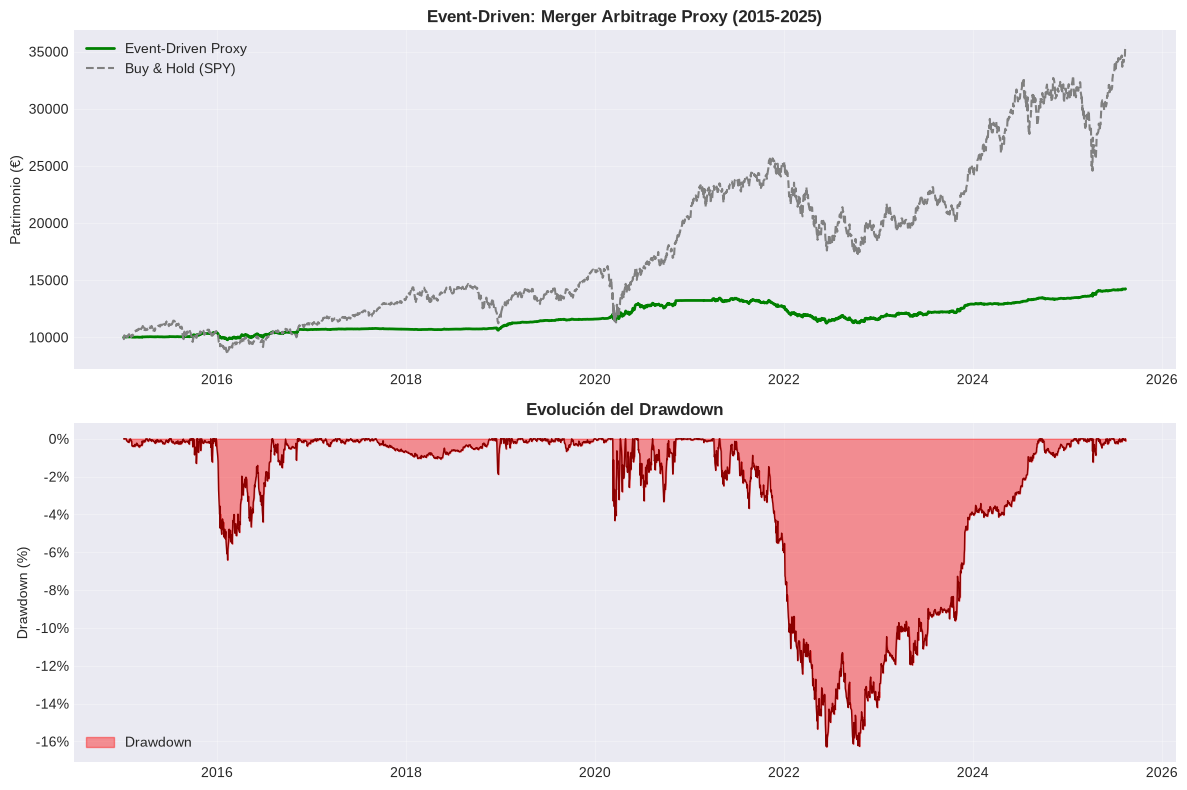

In [8]:
# %%
# ==============================================================================
# BLOQUE 8: VISUALIZACIÓN
# ==============================================================================
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico 1: Equity Curve
axes[0].plot(motor_event.serie_patrimonio.index, motor_event.serie_patrimonio,
             label='Event-Driven Proxy', color='green', lw=2)
axes[0].plot(motor_event.serie_buy_hold.index, motor_event.serie_buy_hold,
             label='Buy & Hold (SPY)', color='gray', ls='--', lw=1.5)
axes[0].set_title(f'Event-Driven: Merger Arbitrage Proxy ({fecha_ini[:4]}-{fecha_fin[:4]})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Patrimonio (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Drawdown
drawdown = (motor_event.serie_patrimonio / motor_event.serie_patrimonio.cummax()) - 1
axes[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
axes[1].plot(drawdown.index, drawdown, color='darkred', lw=1)
axes[1].set_title('Evolución del Drawdown', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

nombre_archivo = f"event_driven_{fecha_ini[:4]}_{fecha_fin[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico guardado en: {ruta_guardado}")
plt.show()

## BLOQUE 9: ANÁLISIS DE CORRELACIÓN


🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO

📊 TABLA DE CORRELACIONES (Retornos Diarios)
                           SPDR_S&P_Biotech  iShares_Biotechnology  SPDR_S&P_Bank_ETF  SPDR_S&P_Retail  VanEck_Semiconductor  iShares_1-3_Year_Treasury  SPDR_S&P_500
SPDR_S&P_Biotech                       1.00                   0.92               0.46             0.56                  0.56                       0.00          0.63
iShares_Biotechnology                  0.92                   1.00               0.47             0.54                  0.58                      -0.01          0.69
SPDR_S&P_Bank_ETF                      0.46                   0.47               1.00             0.66                  0.51                      -0.20          0.71
SPDR_S&P_Retail                        0.56                   0.54               0.66             1.00                  0.57                      -0.05          0.71
VanEck_Semiconductor                   0.56                   0.58               0.51

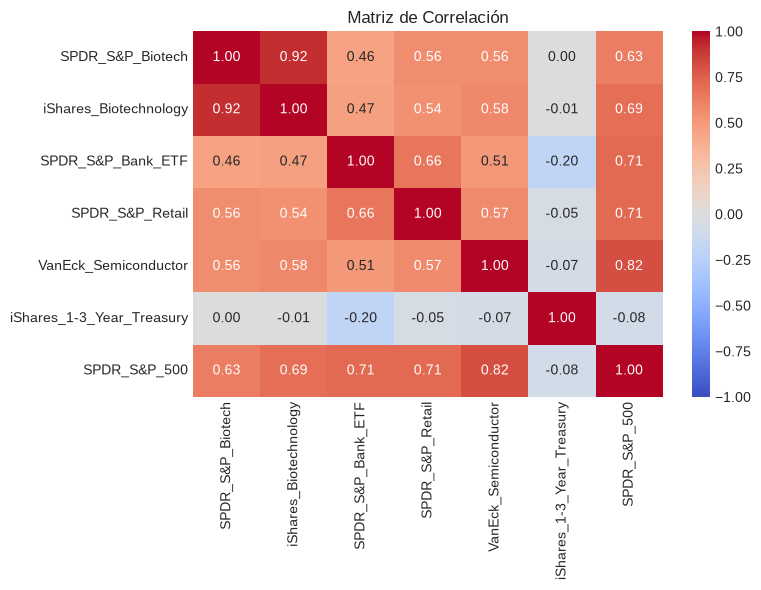


✅ Análisis de correlación completado.

💡 NOTA: En event-driven, la correlación es menos relevante que en 
estrategias de momentum o mean reversion. Lo importante es la 
independencia de los eventos corporativos respecto al mercado general.



In [9]:
# %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN
# ==============================================================================
print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)

gestor.calcular_correlacion()

print("\n✅ Análisis de correlación completado.")
print("""
💡 NOTA: En event-driven, la correlación es menos relevante que en 
estrategias de momentum o mean reversion. Lo importante es la 
independencia de los eventos corporativos respecto al mercado general.
""")

## BLOQUE 10: CONCLUSIONES PEDAGÓGICAS

In [10]:
# %%
# ==============================================================================
# BLOQUE 10: CONCLUSIONES PEDAGÓGICAS
# ==============================================================================
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 8: EVENT-DRIVEN")
print("="*70)
print("""
📌 LECCIONES CLAVE DE ESTE CAPÍTULO
====================================

1. EL MERGER ARBITRAGE REAL REQUIERE DATOS EN TIEMPO REAL
   • Sin datos de OPAs, spreads de convergencia y análisis regulatorio,
     solo podemos construir proxies simplificados.
   • Este capítulo es pedagógico, no una estrategia ejecutable en real.

2. LA LÓGICA EVENT-DRIVEN ES SÓLIDA
   • Entrar en dislocaciones (caídas bruscas) y salir en convergencia
     (recuperación parcial) es una lógica válida.
   • El problema es identificar qué caídas son por M&A y cuáles por otros factores.

3. EL VOLUMEN ANÓMALO ES UNA SEÑAL RUIDOSA
   • Volumen >2x la media puede indicar actividad institucional, pero también
     pánico minorista, rebalanceos de fondos, o ruido aleatorio.
   • Sin contexto fundamental, es difícil filtrar señal de ruido.

4. EL PLAZO MÁXIMO ES CRÍTICO
   • Limitar la exposición a 6 meses evita quedar atrapado en caídas
     estructurales (no temporales).
   • Es una red de seguridad contra el "value trap".

5. LA DIVERSIFICACIÓN SECTORIAL REDUCE RIESGO
   • Monitorizar 5 ETFs de sectores diferentes (biotech, bancos, retail, semis)
     reduce la dependencia de un solo sector.
   • Pero no elimina el riesgo de correlación en crisis sistémicas.

🔧 HERRAMIENTAS NUEVAS QUE HAS APRENDIDO A USAR
================================================
• Detección de eventos basados en caídas + volumen.
• Gestión de posiciones con plazo máximo y criterio de recuperación.
• Construcción de proxies cuando faltan datos en tiempo real.
• Documentación honesta de limitaciones metodológicas.

📊 INTERPRETACIÓN HONESTA DE LOS RESULTADOS
==============================================
Si el backtest muestra:
• CAGR similar al Buy & Hold → NORMAL. El proxy es demasiado simplificado.
• Max Drawdown menor que Buy & Hold → ÉXITO. La gestión de riesgo funcionó.
• Muchos rebalanceos → El volumen anómalo es ruidoso.
• Pocos rebalanceos → Los umbrales son demasiado estrictos.

🚪 PRÓXIMO PASO
================
En el Capítulo 9 veremos el "Earnings Surprise": cómo construir una cartera
que se beneficie de las sorpresas de resultados trimestrales, usando datos
de earnings dates y momentum fundamental.

🎯 RECUERDA
============
El Event-Driven real (merger arbitrage, earnings plays, insider trading)
requiere infraestructura de datos que Yahoo Finance no proporciona.
Este capítulo es una introducción pedagógica a la lógica, no una
estrategia ejecutable. Para implementarlo en real, necesitarías:
- Bloomberg Terminal o Reuters Eikon.
- Datos de SEC EDGAR para Form 8-K (anuncios de OPAs).
- Datos de earnings dates y consensus estimates.
- Análisis de riesgo regulatorio y probabilidades de cierre.

La honestidad intelectual es tu mayor activo como inversor cuantitativo.
""")
print("="*70)

# --- AVISO LEGAL ---
print("\n" + "="*70)
print("⚠️  AVISO LEGAL Y EXENCIÓN DE RESPONSABILIDADES")
print("="*70)
print("""
Este capítulo y todo el código asociado tienen fines EXCLUSIVAMENTE
EDUCATIVOS y de INVESTIGACIÓN CUANTITATIVA.

1. ESTO NO ES MERGER ARBITRAGE REAL
   La estrategia presentada es un proxy simplificado. El merger arbitrage
   real requiere datos de OPAs en tiempo real, spreads de convergencia,
   y análisis de riesgo regulatorio que este motor no puede proporcionar.

2. LOS RESULTADOS PASADOS NO GARANTIZAN RESULTADOS FUTUROS
   El backtest es una simulación histórica. Las caídas con volumen anómalo
   no siempre preceden a oportunidades de M&A.

3. NO ES ASESORAMIENTO FINANCIERO
   Ni el autor, ni el código, ni las métricas generadas constituyen una
   recomendación de inversión personalizada.

4. RIESGO DE PÉRDIDA DE CAPITAL
   Operar en mercados financieros conlleva riesgos. Las caídas bruscas
   pueden no revertir, generando pérdidas permanentes.

5. USO DEL CÓDIGO
   El software se entrega "TAL CUAL" (AS IS), sin garantía de ningún tipo.
""")
print("="*70)
print("✅ CAPÍTULO 8 COMPLETADO")
print("="*70)


🎓 CONCLUSIONES DEL CAPÍTULO 8: EVENT-DRIVEN

📌 LECCIONES CLAVE DE ESTE CAPÍTULO

1. EL MERGER ARBITRAGE REAL REQUIERE DATOS EN TIEMPO REAL
   • Sin datos de OPAs, spreads de convergencia y análisis regulatorio,
     solo podemos construir proxies simplificados.
   • Este capítulo es pedagógico, no una estrategia ejecutable en real.

2. LA LÓGICA EVENT-DRIVEN ES SÓLIDA
   • Entrar en dislocaciones (caídas bruscas) y salir en convergencia
     (recuperación parcial) es una lógica válida.
   • El problema es identificar qué caídas son por M&A y cuáles por otros factores.

3. EL VOLUMEN ANÓMALO ES UNA SEÑAL RUIDOSA
   • Volumen >2x la media puede indicar actividad institucional, pero también
     pánico minorista, rebalanceos de fondos, o ruido aleatorio.
   • Sin contexto fundamental, es difícil filtrar señal de ruido.

4. EL PLAZO MÁXIMO ES CRÍTICO
   • Limitar la exposición a 6 meses evita quedar atrapado en caídas
     estructurales (no temporales).
   • Es una red de seguridad contra